# Estimating $R_0$


$R_0$: "The average/expected number of secondary infections arising from a single individual during his or her entire infectious period, in a population of susceptibles" (Heffernan et al, 2005)

Goal: $R_0$ has not been reliably estimated for E. coli. With the available data set and likelihood-free inference tools, could we find this via simulation?


States:
- $I$: colonized by a specific E. coli strain of interest.
- $R$: decolonized (strain of interest)
- $S$: susceptible to colonization by strain $s$. In other words, colonized by any other strain than $s$ or not colonized at all.

Through simulations, we can find the set of parameters that most closely matches the data. The inferred parameters can be used to determine $R_0$

The simulation will be SIR simulation, where $I$ is actually colonization rather than infection. We do not observe the colonization, but we do observe infection. 
- Step 1: SCR-simulation
- Step 2: "Translate" SCR to BSI using OR data.
- Step 3: Compare the translated BSI to demographic data.

Simplifications:
- Stratification by age groups: at first, no stratification, just see the evolvement of the entire population.
- One-vs-all approach to strains/CCs/STs

Simplifications can be expanded on later.

Future model configurations:
- Stratification by age group, complex strain dynamics
- IBM/ABM with one-vs-all strains. ABM with complex strain dynamics (c++?)



## Population of Norway

https://www.ssb.no/en/statbank/table/06913/tableViewLayout1/


## Practicalities
To install to the correct python version, use `python3 -m pip install seaborn` otherwise will use some old Python v2. Do this via jupyter terminal. Also restart jupyter after installing packages, fixed "ModuleNotFound" error for me :)

Required packages
- xlrd (to read excel files) DEPRECATED support for xlsx files, use `openpyxl` instead.
- Check `doc/` folder for an environment file

## How this works

- The foundation is the unobserved colonisation SIR model.
- The output of this model is then turned into BSI using `or_data`. This is the observational model part.
- Which is then compared with observed demographic data

Details:
- Consider non-colonisation too!

TODO: 
- Create a conversion function for turning the colonisation of the SIR model to BSI cases. This would be the observational model. DONE
- Figure out how to do the BSI-ELFI SIR comparison - might require some trickery. **<- Difficult step** DONE update with new summaries DONE
- Demographic data: get theta_BSI from the actual observations. OK, age distribution

In [2]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy
import graphviz # conda install python-graphviz
import elfi

In [3]:
# load NORM data

norm_data = pd.read_excel("data/mmc2.xlsx", engine = 'openpyxl') # this is the NORM data


# load BSAC data
bsac_data = pd.read_csv("data/Supplemental_Data_S1.csv")


df = norm_data


# load babybiome data
or_data = pd.read_csv("data/ST131_clades_OR_E_coli_carriage_disease_collapsed.csv")


# load population data

norway_pop_data = pd.read_csv("data/Norway_population_2002-2017.csv", sep = '\t', header = 0, index_col = 0)


# load age distribution data
ages = ["0-9", "10-19", "20-29", "30-39", "40-49", "50-59", "60-69", "70-79", "80-89", "90-99", "100-109"]
groups = [61, 22, 67, 97, 131, 255, 556, 767, 900, 316, 3]

norm_age_data = pd.DataFrame(data={"age":ages, "n_BSI":groups})

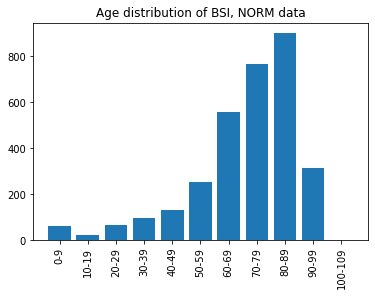

In [4]:
plt.bar(norm_age_data["age"], norm_age_data["n_BSI"])
plt.title("Age distribution of BSI, NORM data")
plt.xticks(rotation=90)
plt.show()

In [5]:
print("Total number of observations:", norm_data.shape[0])
print("ST131 observations:", norm_data.loc[norm_data['ST'] == 131].shape[0])

Total number of observations: 3254
ST131 observations: 272


In [6]:
#print(norm_data.columns)
#norm_data.head()

## Preprocessing of the demographic data

In [7]:
bsac_data = bsac_data.rename(columns = {'Year_of_isolation':'year', 'MLST':'ST', 'Phylogroup':'clade'})
norm_data = norm_data.rename(columns = {'CC131_clades':'clade'})

#bsac_data.head()

In [8]:
# Unique clades in BSAC:
bsac_data['clade'].unique()

array(['D', 'A', 'B2', 'E', 'F', 'B1'], dtype=object)

Clade A does not represent ST131 in BSAC data. Probably makes sense, we are speaking of a different country.

In [9]:
def get_obs_BSI(df, clade, cladecol = 'clade', is_prop = True):
    # Get the proportion of clade out of all observations per year
    
    if 'clade' in df.columns:
        cladecol = 'clade'
        
    if is_prop:
        theta_BSI_obs = pd.value_counts(df.loc[df[cladecol] == clade]["year"])/pd.value_counts(df["year"])# n clades per year/n all ST131 obs
    else:
        theta_BSI_obs = pd.value_counts(df.loc[df[cladecol] == clade]["year"]).sort_index() # these are counts directly

    
    return theta_BSI_obs.fillna(0) # assume that years with missing obs did not have any BSI cases.


data = bsac_data
clade = "A"

print(get_obs_BSI(norm_data, clade = "A", is_prop = True))

2002    0.024096
2003    0.000000
2004    0.008000
2005    0.000000
2006    0.023622
2007    0.007143
2008    0.018868
2009    0.010417
2010    0.025510
2011    0.013514
2012    0.039711
2013    0.047059
2014    0.041509
2015    0.013201
2016    0.026667
2017    0.025352
Name: year, dtype: float64


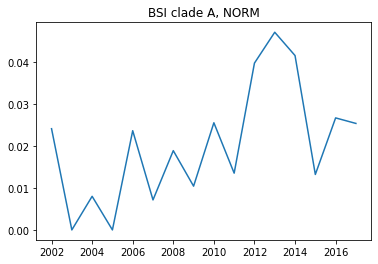

In [10]:
# Visualize the observed data
data = norm_data
clade = 'A'
dataname = "NORM"
#print(np.nan_to_num(get_obs_BSI(data, clade, is_prop = True)))

plt.plot(get_obs_BSI(data, clade, is_prop = True))
plt.title(f"BSI clade {clade}, {dataname}")

plt.show()


## Replicating Odds Ratio calculations


Invasiveness is the ratio of the frequencies of carriage (newborns) and disease (BSI).


OR = (c0/d0)/(ca/da) = da/ca * c0/d0 = (da/ca)/(d0/c0)


$$OR = \frac{inv_a}{inv_0} = \frac{\frac{d_a}{c_a}}{\frac{d_0}{c_0}} = \frac{d_ac_0}{c_ad_0}$$

Odds ratio is calculated between `PP` and `nonPP`. PP = popPUNK. PP = clade A, nonPP = not clade A for example. 

Rebecca's message: 

$$OR = \frac{inv_a}{inv_0} = \frac{d_ac_0}{c_ad_0},$$ where $a = $ clade A for example, and zero means non-clade A.

Now it makes sense!

**Q**: Why are there more disease than carriage cases? **A**: Different data. Carriage from the babybiome data, so only a sample of newborns.


In [11]:

print((or_data['carriage_nonPP']/or_data['Disease_nonPP'])/(or_data['carriage_PP']/or_data['Disease_PP'])) # this is how the OR is calculated.
#print(or_data["OR"]) # to check

# disease_nonPP + diseasePP = number of observations in BSAC/NORM

0     0.570639
1     0.308431
2     0.486962
3     0.718294
4     0.854069
5     0.761170
6     2.192996
7     1.475790
8     1.964676
9     0.697055
10    4.092271
11    1.719398
12    1.545298
13    0.802915
14    1.005647
dtype: float64


# ELFI

Clade of interest vs all. So baseline/defnition of a susceptible population = no clade X colonization.

[ELFI documentation](https://elfi.readthedocs.io/en/latest/)

Components in ELFI graph
- TODO: Simulators, summaries etc.

Local installation:
- `pip3 install elfi`


The objective: First simulate colonization with an SCR model (SIR, but I = colonization). Then use an observational model to "translate" colonization to BSI. Then compare this "translated" BSI to the colonization.


# Converting simulated colonization to BSI

Estimate of OR: $N(OR, \sigma)$ 

Invasiveness of E.coli is calculated as follows:

$inv = \frac{f_{disease}}{f_{carriage}}$

What to do:
- Simulate colonization with SIR model
- Convert colonization to BSI via OR data
- Compare converted BSI with the data.
- Enjoy!!!


Note that invasiveness =/= force of colonization

Base carriage rate for E.coli is assumed constant over time and over all age groups.


OR = 2 means that clade B is twice as likely to cause BSI non-B clades.

### Derivation of $\theta_{BSI, A}$ from the odds ratios

$\theta_{C,A}$ is the proportion of individuals colonized by clade A. 
Here A = clade A and 0 = other clades. BSI = blood stream infection, C = carriage.

The derivation:


$$\hat{OR} = \frac{inv_A}{inv_0} = \frac{\theta_{BSI,A}\theta_{C,0}}{\theta_{C,A}\theta_{BSI,0}}$$

$$\hat{OR}\theta_{C,A}\theta_{BSI,0} = \theta_{BSI,A}\theta_{C,0}$$

$$\theta_{BSI,A} = \frac{\hat{OR}\theta_{C,A}\theta_{BSI,0}}{\theta_{C,0}}$$

Assume: $\theta_{X,A} = \theta_{X} - \theta_{X,0}$

$$\theta_{BSI,A} = \frac{\hat{OR}\theta_{C,A}\theta_{BSI}}{\theta_{C} - \theta_{C,A} + \hat{OR}\theta_{C,A}}$$

Known quantities from the data: $\theta_{BSI, A}$, $\theta_{BSI,0}$.  $\theta_{C,0}$ is known through the known parameter $\theta_{C}$ which represents the proportion of colonized individuals of the entire population.
OR is simulated based on the odds ratios.

How to get $\theta_{BSI,0}$ (or $\theta_{C,0}$): $\theta_{X,0} = \theta_{X} - \theta_{X,A}$ 

OR is simulated as follows:

$$\hat{OR} \sim N(\mu, \sigma^2),$$ where $\mu$ and $\sigma$ are deduced from the odds ratios.


**Alternative: counts**

Assumptions: 
- We know the number of colonized individuals (by any E.coli strain. Make an educated guess or simulate a population were everyone is colonized by E.coli)
- We know all BSI cases in the population (we do, from data)
- Assume that $\theta_{x,A} = \frac{N_{x,A}}{N}$, where $N$ is the population of interest (for example entire Norway or an age group)
- $N_{X,0} = N_{X} - N_{X,A}$ (thus, given the above, $\frac{N_{X,0}}{N} = \frac{N_{X}}{N} - \frac{N_{X,A}}{N}$ -> $\theta_{X,0} = \theta_{X} - \theta_{X,A}$

$$OR = \frac{N_{BSI,A}}{N}\frac{N}{N_{C,A}}\frac{N_{C,0}}{N}\frac{N}{N_{BSI,0}}$$
$$OR = \frac{N_{BSI,A}}{N_{C,A}}\frac{N_{C,0}}{N_{BSI,0}}$$
$$OR = \frac{N_{BSI,A}}{N_{C,A}}\frac{N_{C,0}}{N_{BSI} - N_{BSI, A}}$$
$$OR = \frac{N_{BSI,A}}{N_{C,A}}\frac{N_{C} - N_{C,A}}{N_{BSI} - N_{BSI, A}}$$
$$ORN_{BSI} - ORN_{BSI, A} = \frac{N_{BSI,A}}{N_{C,A}}(N_{C} - N_{C,A})$$
$$ORN_{BSI} - ORN_{BSI, A} = \frac{N_{BSI,A}N_{C} - N_{BSI,A}N_{C,A}}{N_{C,A}}$$
$$ORN_{BSI}N_{C,A} - ORN_{BSI, A}N_{C,A} = N_{BSI,A}N_{C} - N_{BSI,A}N_{C,A}$$
$$ ORN_{BSI, A}N_{C,A} + N_{BSI,A}N_{C} - N_{BSI,A}N_{C,A} = ORN_{BSI}N_{C,A}$$
$$ N_{BSI, A}(ORN_{C,A} + N_{C} - N_{C,A}) = ORN_{BSI}N_{C,A}$$
$$ N_{BSI, A} = \frac{ORN_{BSI}N_{C,A}}{ORN_{C,A} + N_{C} - N_{C,A}}$$


### Thoughts on the population size N

There are two alternative interpretations:


**a)** $\theta_{C, A} = \frac{N_{C,A}}{N}$

**b)** $\theta_{C, A} = \frac{N_{C,A}}{N_{C}}$


When considering the OR, this choice does not matter since $N$ (or $N_C$) cancels out. In both cases, the following hold:

$$N_C = N_{C,A} + N_{C,0}$$

$$\theta_C = \frac{N_C}{N}$$

The difference is as follows:

**Option a)**, population is $N$ (one age group or for example the entire population of Norway.


$N_C = N_{C,A} + N_{C,0}$

$\theta_CN = \theta_{C,A}N + \theta_{C,0}N$  Divide this by $N$

$\theta_C = \theta_{C,A} + \theta_{C,0}$

**Option b)**, We consider the proportion of clade A colonizations to be from all colonizations, not the entire population

$N_C = N_{C,A} + N_{C,0}$

$N_C = \theta_{C,A}N_C + \theta_{C,0}N_C$  Divide this by $N_C$

$\theta_{C,A} + \theta_{C,0} = 1$




Current implementation supports both options with the `theta_c` parameter. Input 1 to use option a) and `theta_c < 1` to use option b).


**Obvious restrictions:**
- $\theta_{C,X}$ <= $\theta_C$
- $\theta_{C,A} + \theta_{C,0} <= 1$

In [12]:
or_data.head()

,Collection,Clade,Label,carriage_nonPP,Disease_nonPP,carriage_PP,Disease_PP,OR,lower,upper,pval_f<=5_chi>5,p.adj BH
0,NORM,A,A (NORM),387,3179,16,75,0.5706,0.3292,0.9890,0.0429,0.1287
1,BSAC,A,A (BSAC),387,1490,16,19,0.3084,0.1571,0.6054,0.0003,0.0018
2,Combined,A,A (Combined),387,4669,16,94,0.4870,0.2837,0.8357,0.0077,0.0308
3,NORM,B,B (NORM),389,3172,14,82,0.7183,0.4036,1.2784,0.2585,0.3878
4,BSAC,B,B (BSAC),389,1464,14,45,0.8541,0.4640,1.5721,0.6120,0.6303


## Observational model

**Assumptions**
- Fully colonized population. Can be changed by tweaking $\theta_c$.
- $\theta_{BSI,0} + \theta_{BSI,A} = 1$


**Other**
- This should by default support stratification by age groups: simply change the parameters ($\theta_{BSI}$) to reflect the age group of interest. 

In [13]:
# Observational model

clade = "A"
dataset = "Combined"

df = or_data[or_data["Label"] == f'{clade} ({dataset})']
nt = 100 # number of observed time points


def get_OR_hat_pars(or_data, clade = "A", dataset = "NORM"):
    
    df = or_data[or_data["Label"] == f'{clade} ({dataset})']
    or_mu = df["OR"]
    or_sd = (df["upper"] - df["lower"])/2
    
    return or_mu, or_sd
    
def get_OR_hat(or_data, clade = "A", dataset = "NORM", batch_size = 1, random_state = None):
    # TODO: fix that random state
    or_mu, or_sd = get_OR_hat_pars(or_data, clade = clade, dataset = dataset)

    OR_hats = np.empty(batch_size)
    
    for b in range(0, batch_size):
        OR_hat = np.random.normal(or_mu, or_sd**2, 1)

        max_iter = 1000
        i = 0

        while OR_hat[0] < 0:
            OR_hat = np.random.normal(or_mu, or_sd**2, 1)
            i = i + 1
            if i == max_iter:
                break

        if i > 0:
            print(f"Iterated OR_hat {i} times due to negativity.")

        if OR_hat < 0:
            print(f"Warning, negative OR_hat after max iterations!")

        OR_hats[b] = OR_hat
    
    return OR_hats

def col_to_BSI(SIR, OR_hat, theta_c = 1, theta_bsi = 0.3, is_prop = True):
    # SIR: output of the SIR simulator (clade of interest colonization proportion over time)
    # theta_bsi: The proportion of bsi in the entire (colonized) population - from the age distribution.
    # theta_c: The overall proportion of population colonized by E. coli. For simplicity, assume we are only interested in the colonized 
    # population and set theta_c = 1 by default.
    # By changing is_prop = False, can work with counts instead of proportions
    
    theta_c_a = SIR[1]
    
    if not is_prop: 
        N = SIR[0][0][0] + 1 # the first entry in S compartment + 1 is the population size.
        theta_c = N*theta_c 
        theta_bsi = theta_bsi*N
    else:
        if np.min(np.max(SIR[1][:,], axis = 1)) > 1:
            print("Warning! col_to_BSI uses proportions, but SIR seems to use counts.")
    
    bs = theta_c_a.shape[0]
    n_obs = theta_c_a.shape[1] # with batches. 0 = first batch

    theta_c_0 = theta_c - theta_c_a

    theta_bsi_a_hat = OR_hat.reshape(-1,1)*theta_c_a*theta_bsi/(theta_c_0 + OR_hat.reshape(-1,1)*theta_c_a)
    
    return theta_bsi_a_hat

def plot_col_to_BSI(SIR, or_data = or_data, clade = "A", dataset = "NORM", n_rep = 100, theta_c = 1, theta_bsi = 0.3, is_prop = True):
    # Plot n_rep repetitions of theta_BSI_clade as "translated" from colonization by clade of interest.
    
    
    all_bsi_reps= []
    for i in range(0, n_rep):
        or_hat = get_OR_hat(or_data, clade = clade, dataset = dataset)
        obsBSI = col_to_BSI(SIR, or_hat, theta_c = theta_c, theta_bsi = theta_bsi, is_prop = is_prop)
        if i == 0:
            plt.plot(obsBSI[0], color = "lightblue", label = "Theta_bsi_A")
        else:
            plt.plot(obsBSI[0], color = "lightblue")
        all_bsi_reps.append(obsBSI)

    plt.plot(SIR[1][0], color = "red", label = "theta_c_A")
    plt.plot(np.mean(all_bsi_reps, axis = 0)[0], color = "navy", label = "Mean of BSI reps")
    plt.xlabel("Years")
    if is_prop:
        plt.title(f"Proportion of BSI: Clade {clade}, {dataset}")
        plt.ylabel("Proportion")
    else:
        plt.title(f"Number of BSI cases: Clade {clade}, {dataset}")
        plt.ylabel("Count")       
    plt.legend()
    plt.show()


# "Biological" requirements/assumptions:
# - If all hosts are colonized by clade A, then all BSIs are caused by clade A. (theta_c_a = 1 -> theta_BSI_a = 1)
# - If no host is colonized by clade A, then no BSI should be caused by clade A. (theta_c_a = 0 -> theta_BSI_a = 0)
# - theta_X <= 1 (we are working with proportions; no proportion should be more than 1.)

In [14]:
test_theta_c = 10

test_BSI = np.array([[1,2,3,4], [1,2,5,7]])

test_theta_c - test_BSI # batches work well

array([[9, 8, 7, 6],
       [9, 8, 5, 3]])

# SIR model with ELFI

Currently using SMC-ABC with adaptive threshold. 

Thoughts:
- ELFI can handle a SIR model with multiple outputs (S, I, R counts namely)
    - Diagnosis: it can run, but will not yield correct results, at least not for a simple SIR model :)
    - It got beta right, but screwed up gamma
- Testing: return only the number of infected cases from `simpleSIR`
    - Now it gets gamma roughly right but not beta...
    - Adding more summary statistics worked

Lintusaari et al 2017:
- Tuberculosis example: number of infectious hosts used as the "y" here. Summary statistics based on genetic diversity and number of clusters (cluster = closely related strains(?))

McKinley et al 2009: 
- Epidemic models often have a lot of correlation between params
- Prior knowledge can for example be the length of infectious period determined in a previous study

Thoughts on the summary statistic:
- Mean number of infectious hosts is probably not the best, especially since the oserved data is simulated until all are in the R category. Solution: use observations up to a predefined number of infetious hosts, like 50. Solution 2: use something else as the summary statistic. Maybe even maximum number of infected/infectious hosts during the simulation?
- What if I attempt to use S and R as well for summary statistics?

Assumptions
- Constant population size $N$ seems reasonable, given how short a time period we are using
- Constant $\beta$ and $\gamma$ (does this make sense?)
- Homogeneous mixing of population (does not really hold, especially if we consider age structure etc demographics later on)


### SIR model in terms of proportions:

$$\frac{d\theta_S(t)}{dt} = -\beta\theta_S(t)\theta_I(t)$$

$$\frac{d\theta_I(t)}{dt} = \beta\theta_S(t)\theta_I(t) - \alpha\theta_I(t)$$

$$\frac{d\theta_R(t)}{dt} = \alpha\theta_I(t)$$

In [15]:
# True value for theta_BSI, A from the data:

df = pd.read_csv("data/ST131_clades_OR_E_coli_carriage_disease_collapsed.csv")


clade = "A"
data = "Combined"
print(f'{clade} ({data})')
theta_BSI_a_true = df[df["Label"] == f'{clade} ({data})']["Disease_PP"]/(df[df["Label"] == f'{clade} ({data})']["Disease_PP"] + df[df["Label"] == f'{clade} ({data})']["Disease_nonPP"])
theta_BSI_a_true

# The estimated value is way too small but yeehaw, it makes at least somewhat sense :)

A (Combined)


2    0.019735
dtype: float64

In [16]:
def prop_bsi_a(thetaI, theta_C, theta_BSI, mu_OR, var_OR, OR_size = 1000):
    
    theta_a = np.max(thetaI) # I compartment, here carriage. At maximum, just because - change later.
    theta_0 = theta_C - theta_a
    
    OR_hat = np.random.normal(mu_OR, var_OR, size = OR_size) # get the OR
    
    theta_BSI_a = OR_hat*theta_BSI*theta_a/(theta_0 + OR_hat*theta_a)
    #theta_BSI_a = OR_hat*theta_a/(OR_hat*theta_a + theta_0)
    
    #plt.hist(theta_BSI_a)
    #plt.show()
    
    return theta_BSI_a

def dS(S, I, t, beta, N, is_prop = False):
    if is_prop:
        #print(f'S[t]: {S[:,t].shape}')
        return -beta*S[:,t]*I[:,t]#.reshape(-1,1)
    return -beta*S[:,t]*I[:,t]/N[t]

def dI(I, S, t,beta, gamma, N, is_prop = False):
    
    if is_prop:
        return beta*S[:,t]*I[:,t] - gamma*I[:,t]
    return beta*S[:,t]*I[:,t]/N[t] - gamma*I[:,t]

def dR(I, t, gamma):
    
    return gamma*I[:,t]


def plot_SIR(SIR):
    # plot SIR
    
    # plot first batch of S, I and R
    plt.plot(SIR[0][0], label = "S") 
    plt.plot(SIR[1][0], label = "I")
    plt.plot(SIR[2][0], label = "R")
    plt.legend(loc = "upper right")
    
    plt.show()
    
def plot_SIR_and_BSI(y, OR_hat):
    # y: I compartment values of an SIR simulation 
    
    y_bsi = col_to_BSI(y, OR_hat = OR_hat)
    #print(y[0][0]) # S and 1st batch

    #print(y)
    # Plot some simulated colonization and then BSI as determined from that colonization
    plt.plot(y[0][0], label = "Not colonized or colonized by another clade (S)")
    plt.plot(y[1][0], label = "Colonized by clade of interest (I)")
    
    if len(y_bsi) > 1:
        plt.plot(y_bsi[0][0], label = "BSI associated with the clade of interest")
    else:
        plt.plot(y_bsi[0], label = "BSI associated with the clade of interest")
    plt.legend(loc = 'upper right')
    plt.show()
    
def plot_BSI(y_bsi):
    
    if len(y_bsi) > 1:
        plt.plot(y_bsi[0][0], label = "BSI associated with the clade of interest")
    else:
        plt.plot(y_bsi[0], label = "BSI associated with the clade of interest")
    plt.legend()
    plt.show()

def check_SIR_nonneg(comp_t, dcomp):
    # Checks that the new value in this compartment is nonnegative. If not, add zero to comp
    # Check also that no compartment goes over 1
    # Note: This is for proportional SIR!
    # comp: compartment of interest, S, I or R for example
    # dcomp: change in the compartment
    # comp_t: current value in the compartment
    
    comp_t1 = comp_t + dcomp
    
    comp_t1[comp_t1 < 0] = 0 # set negative values to zero
    comp_t1[comp_t1 > 1] = comp_t[np.where(comp_t1 > 1)] # If any proportion goes above 1 after addition
    
    return comp_t1

def propSIR_simulator(beta, gamma, nt, N, batch_size = 1, random_state = None):
    # SIR simulator. Outputs a tuple with S, I and R observations.
    # nt: number of time points to simulate
    # N: population size
    
    # set negative values to zero
    beta[beta < 0] = 0
    gamma[gamma < 0] = 0
        
    thetaS = np.zeros((batch_size, nt))
    thetaI = np.zeros((batch_size, nt))
    thetaR = np.zeros((batch_size, nt))
    
    thetaS[:,0] = N-1
    thetaI[:,0] = 1
    thetaR[:,0] = 0
    

    thetaS[:,0] = thetaS[:,0]/N # recommendation: make S0 the same as N - I0
    thetaI[:,0] = thetaI[:,0]/N
    thetaR[:,0] = thetaR[:,0]/N
    
    N = np.array([N]*nt)

    for t in range(0, nt-1):

        #thetaS[:,t + 1] = thetaS[:,t] + dS(thetaS, thetaI, t, beta, N, is_prop = True)
        #thetaI[:,t + 1] = thetaI[:,t] + dI(thetaI, thetaS, t, beta, gamma, N, is_prop = True)
        #thetaR[:,t + 1] = thetaR[:,t] + dR(thetaI, t, gamma)
        
        thetaS[:,t + 1] = check_SIR_nonneg(thetaS[:,t], dS(thetaS, thetaI, t, beta, N, is_prop = True))
        thetaI[:,t + 1] = check_SIR_nonneg(thetaI[:,t], dI(thetaI, thetaS, t, beta, gamma, N, is_prop = True))
        thetaR[:,t + 1] = check_SIR_nonneg(thetaR[:,t], dR(thetaI, t, gamma))
        
    return thetaS, thetaI, thetaR

def prop_to_nSIR(SIR, N):
    # Convert proportions to counts in a SIR model
    
    S = SIR[0]
    I = SIR[1]
    R = SIR[2]
    
    return S[:,]*N, I[:,]*N, R[:,]*N


def SIR_and_BSI_simulator(beta, gamma, nt, N, bsi_pars, is_prop = False, is_agg = False, time_period = 52, batch_size = 1, random_state = None):
    # A simulator function combining both the SIR simulation and the observational model
    
    
    # SIR simulator:
    SIR = propSIR_simulator(beta = beta, gamma = gamma, nt = nt, N = N, batch_size = batch_size, random_state = random_state)
    
    if not is_prop:
        SIR = prop_to_nSIR(SIR, N)
        
    # Observational model:
    
    or_data = bsi_pars["or_data"]
    clade = bsi_pars["clade"]
    dataset = bsi_pars["dataset"]
    theta_c = bsi_pars["theta_c"]
    theta_bsi = bsi_pars["theta_bsi"]
    
    
    or_hat = get_OR_hat(or_data, clade, dataset, batch_size = batch_size, random_state = random_state)
    
    BSI = col_to_BSI(SIR, or_hat, theta_c = theta_c, theta_bsi = theta_bsi, is_prop = is_prop)
    
    if is_agg:
        BSI = sum_over_bsi(BSI, time_period = time_period)

    return BSI


Iterated OR_hat 4 times due to negativity.


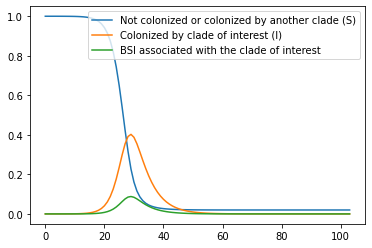

In [17]:
import random

pSIR_test = propSIR_simulator(np.array([0.72]), np.array([0.2]), 104, 100000, batch_size = 1)
or_hat = get_OR_hat(or_data, clade = "C1", dataset = "NORM")
plot_SIR_and_BSI(pSIR_test, OR_hat = or_hat)

In [18]:
or_data.head()

,Collection,Clade,Label,carriage_nonPP,Disease_nonPP,carriage_PP,Disease_PP,OR,lower,upper,pval_f<=5_chi>5,p.adj BH
0,NORM,A,A (NORM),387,3179,16,75,0.5706,0.3292,0.9890,0.0429,0.1287
1,BSAC,A,A (BSAC),387,1490,16,19,0.3084,0.1571,0.6054,0.0003,0.0018
2,Combined,A,A (Combined),387,4669,16,94,0.4870,0.2837,0.8357,0.0077,0.0308
3,NORM,B,B (NORM),389,3172,14,82,0.7183,0.4036,1.2784,0.2585,0.3878
4,BSAC,B,B (BSAC),389,1464,14,45,0.8541,0.4640,1.5721,0.6120,0.6303


3
(104,)


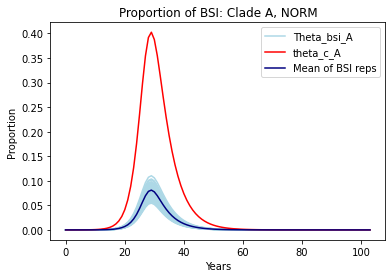

In [19]:
# Conversion of colonization to BSI; test
y = propSIR_simulator(np.array([0.72]), np.array([0.2]), nt = 104, N = 100000, batch_size = 3)
y_bsi = col_to_BSI(y, OR_hat = or_hat)
print(len(y_bsi))
print(y_bsi[0].shape)
plot_col_to_BSI(y, or_data, clade = "A", dataset = "NORM")


Data is in the format $(S, I)$, where $S = n x n_{batch}$ and $I = n x n_{batch}$

In [20]:
# Distance metrics

def I_mean(y):
    #print(y)
    #print(y[1])
    return np.mean(y[1][:,], axis=1)

def I_var(y):
    return np.var(y[1][:,], axis=1)

def I_max(y):
    return np.max(y[1][:,], axis = 1)

def S_min(y):
    return np.min(y[0][:,], axis=1)

def R_max(y):
    return np.max(y[2][:,], axis=1)

def I_max_bsi(y):
    I_max = np.max(y[:,], axis = 1)
    return I_max#.reshape(-1,1)

def I_mean_bsi(y):
    I_mean = np.mean(y[:,], axis = 1)
    return I_mean#.reshape(-1,1)

def I_var_bsi(y):
    return np.var(y[:,], axis = 1)#.reshape(-1,1)

In [21]:
# New summaries

def BSI_max_t(y):
    # time to peak/maximum number of bsi cases
    
    return np.argmax(y, axis = 1)

def BSI_max(y):
    # maximum number of BSI cases
    
    max_bsi = np.max(y[:,], axis = 1)
    
    return max_bsi#.reshape(-1,1).transpose()

def BSI_k1(y, time_period = 1):
    # Slope between max BSI cases and the previous yearly observation
    # time_period: 52 for non-aggregate BSI simulation, 1 for aggregated.
    
    max_bsi = np.max(y[:,], axis = 1)
    bs = y.shape[0]
    t_max = np.asarray([np.where(y[b] == max_bsi[:,][b])[0] for b in range(0,bs)]).transpose()[0]

    
    prev_t = t_max[0] - time_period # One time period of interest before max
    if prev_t < 0:
        prev_t = 0
    prev_bsi = y[:,prev_t]

    k1 = (max_bsi - prev_bsi)/(t_max[0] - prev_t)
    
    return k1

def BSI_k2(y):
    # Slope between year before the max and the observation two years before it.
    pass


Potential summaries:
- Time of the max proportion of colonized hosts

### Making aggregates of BSI observations

Observational model + SIR: outputs data in weeks. 
Actual observed data: yearly.
Problem: comparing these.

Solutions:
- Functions to aggregate the output of the observational model
- Summaries that would work for both the obs model data and observed data
    - Tangent - "speed" of infection
    - Maximum number of BSI
    
Issues:
- Taking a "point" value (i.e., every 52th proportion of the bsi observations) will miss the highest peak. Also summation for proportional data probably doesn't make sense, since the BSI curve already depicts the proportion of *all* BSI cases for each week. 
    - Instead, maybe the maximum proportion of BSI cases per year? Or use counts for the simulation.
- Applies to count data, too. For example, if we have 200 cases in week 2 and then 400 in week 3, we can't know if the 400 contain the previous 200 obs or not. That is why this method gives too large numbers - duplicates are calculated as unique cases. The model yields all BSI cases at a particular time point, but does not ensure no duplicates. 
    - Although, does it matter? Using summaries we can probably constrain this later in the pipeline.


In [22]:
pop_size = 100000
n_weeks = 800
SIR_obs = prop_to_nSIR(propSIR_simulator(np.array([0.732]), np.array([0.23]), nt = n_weeks, N = pop_size, batch_size = 3), pop_size)
OR_hat = get_OR_hat(or_data, clade = "A", dataset = "NORM")
bsi_obs = col_to_BSI(SIR_obs, OR_hat = OR_hat, is_prop = False)#.reshape(-1,1)
#bsi_obs = (aggregate_BSI(bsi_obs), aggregate_BSI(bsi_obs), aggregate_BSI(bsi_obs))

def aggregate_BSI(bsi_obs, nan_locations  = [], batch_size=1):
    # Pick every 52th observation from bsi_obs
    return bsi_obs[:,::52]

def sum_over_bsi(bsi_obs, time_period = 52):
    # Take a sum over every ith week in bsi_obs (from i to i + time_period, where i is the current week)
    # Note: probably not applicable for proportion observations, only counts
    # time_period: time period to sum over. By default 52 (weeks).
    
    n_years = len(bsi_obs[0])//52
    #print(f'Number of years to sum: {n_years}')
    agg_bsi = []
    for i in range(0, n_years):
        start = i*time_period # which week to start summing at
        end = time_period*i + time_period # next week
        bsi_obs_yearly = bsi_obs[:,start:end]
        agg_bsi.append(np.sum(bsi_obs_yearly[:,], axis = 1))
    agg_bsi = np.asarray(agg_bsi).transpose()   
    
    return agg_bsi

def max_bsi_per_year(bsi_obs, time_period = 52):
    # Return the maximum number of BSI cases per year
    
    n_years = len(bsi_obs[0])//52
    agg_bsi = []
    
    for i in range(0, n_years):
        start = i*time_period # which week to start summing at
        end = time_period*i + time_period # next week
        agg_bsi.append(np.max(bsi_obs[:,start:end], axis = 1))
    agg_bsi = np.asarray(agg_bsi).transpose()  
    
    return agg_bsi


# test aggregate over summaries:
y = sum_over_bsi(bsi_obs)
print(y)
print(BSI_max_t(y))
print(BSI_max(y))
#print(BSI_k1(y))

[[6.10722009e+04 2.49799780e+02 1.65480814e-03 1.09630442e-08
  7.26297723e-14 4.81169620e-19 3.18773136e-24 2.11186052e-29
  1.39909997e-34 9.26898683e-40 6.14067032e-45 4.06817192e-50
  2.69514921e-55 1.78552663e-60 1.18290494e-65]
 [6.10722009e+04 2.49799780e+02 1.65480814e-03 1.09630442e-08
  7.26297723e-14 4.81169620e-19 3.18773136e-24 2.11186052e-29
  1.39909997e-34 9.26898683e-40 6.14067032e-45 4.06817192e-50
  2.69514921e-55 1.78552663e-60 1.18290494e-65]
 [6.10722009e+04 2.49799780e+02 1.65480814e-03 1.09630442e-08
  7.26297723e-14 4.81169620e-19 3.18773136e-24 2.11186052e-29
  1.39909997e-34 9.26898683e-40 6.14067032e-45 4.06817192e-50
  2.69514921e-55 1.78552663e-60 1.18290494e-65]]
[0 0 0]
[61072.2008509 61072.2008509 61072.2008509]


Text(0.5, 0, 'Years')

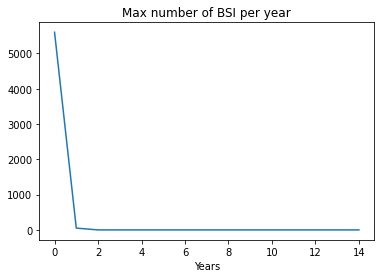

In [23]:
plt.plot(max_bsi_per_year(bsi_obs)[0])
plt.title("Max number of BSI per year")
plt.xlabel("Years")

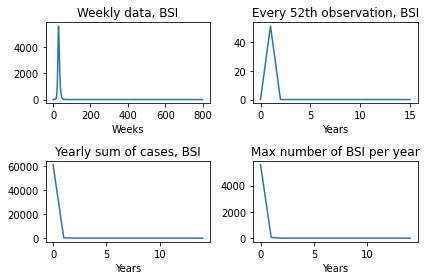

In [24]:
fig, axs = plt.subplots(2,2)

axs[0,0].plot(bsi_obs[0])
axs[0,0].set_title("Weekly data, BSI")
axs[0,0].set_xlabel("Weeks")

axs[0,1].plot(aggregate_BSI(bsi_obs)[0])
axs[0,1].set_title("Every 52th observation, BSI")
axs[0,1].set_xlabel("Years")

axs[1,0].plot(sum_over_bsi(bsi_obs)[0])
axs[1,0].set_title("Yearly sum of cases, BSI")
axs[1,0].set_xlabel("Years")

axs[1,1].plot(max_bsi_per_year(bsi_obs)[0])
axs[1,1].set_title("Max number of BSI per year")
axs[1,1].set_xlabel("Years")

fig.tight_layout()

# ELFI models

In [25]:
# "observed" data
#bsi_pars = {"theta_C":0.6, "theta_BSI": 0.05, "mu_OR":0.4, "var_OR":0.6, "OR_size":100}
#params = {"S0": 100000 - 1, "I0": 1, "R0":0, "times":[i for i in range(0,104)],"timestep":1, "N":100000}
#pSIR_obs = propSIR_simulator(beta = 0.72, gamma = 0.2) # This is what I would need from the observational model
#print(pSIR_obs[1])


# Specifying data-related parameters:

bsi_obs_data = get_obs_BSI(df = norm_data, clade = "A", is_prop = True)
print(bsi_obs_data)

n_years = max(bsi_obs_data.index) - min(bsi_obs_data.index) # years of interest
n_weeks = (n_years + 1)*52 # weeks of interest
print(f'Number of weeks to simulate: {n_weeks}')

pop_size = 100000
print(f'Population size: {pop_size}')

print(bsi_obs_data)

2002    0.024096
2003    0.000000
2004    0.008000
2005    0.000000
2006    0.023622
2007    0.007143
2008    0.018868
2009    0.010417
2010    0.025510
2011    0.013514
2012    0.039711
2013    0.047059
2014    0.041509
2015    0.013201
2016    0.026667
2017    0.025352
Name: year, dtype: float64
Number of weeks to simulate: 832
Population size: 100000
2002    0.024096
2003    0.000000
2004    0.008000
2005    0.000000
2006    0.023622
2007    0.007143
2008    0.018868
2009    0.010417
2010    0.025510
2011    0.013514
2012    0.039711
2013    0.047059
2014    0.041509
2015    0.013201
2016    0.026667
2017    0.025352
Name: year, dtype: float64


In [26]:
SIR_obs = prop_to_nSIR(propSIR_simulator(np.array([0.734]), np.array([1/30]), nt = n_weeks, N = pop_size, batch_size = 1), pop_size)
OR_hat = get_OR_hat(or_data, clade = "A", dataset = "NORM")
bsi_obs = sum_over_bsi(col_to_BSI(SIR_obs, OR_hat = OR_hat, is_prop = False))

bsi_obs

array([[3.80663830e+05, 1.22248880e+05, 1.86731488e+04, 3.14560953e+03,
        5.37970852e+02, 9.22402835e+01, 1.58223886e+01, 2.71428822e+00,
        4.65634825e-01, 7.98796036e-02, 1.37033425e-02, 2.35080796e-03,
        4.03281032e-04, 6.91828488e-05, 1.18683156e-05, 2.03600918e-06]])

In [27]:
def BSI_max_t(y):
    # time to peak/maximum number of bsi cases
    # shaped (batch_size, n_obs)
    
    return np.argmax(y, axis = 1)

def BSI_max(y):
    # maximum number of BSI cases
    
    max_bsi = np.max(y[:,], axis = 1)
    
    return max_bsi

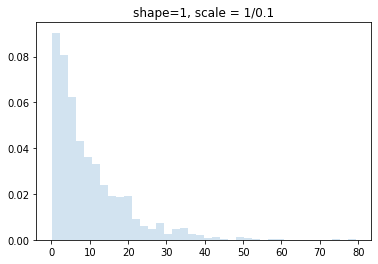

In [28]:
r = scipy.stats.gamma.rvs(1,0,1/0.1, size=1000)
plt.hist(r, density=True, bins='auto', histtype='stepfilled', alpha=0.2)
plt.title("shape=1, scale = 1/0.1") # shape = 1, scale = 0.2
plt.show()

In [40]:
# A simple SIR with elfi

elfi.new_model()

# simulated data, proportions:
#SIR_obs = propSIR_simulator(0.734, 1/30, nt = n_weeks, N = pop_size, batch_size = 1)   
#OR_hat = get_OR_hat(or_data, clade = "A", dataset = "NORM")
#bsi_obs = col_to_BSI(SIR_obs, OR_hat = OR_hat)

# simulated data, counts with a summation aggregate:
agg_bsi = True
is_p = True
clade = "A"

# Actual data:
#bsi_obs = np.asarray(get_obs_BSI(norm_data, clade = clade)).reshape(1,-1)
#print(bsi_obs)

bsi_pars = {"or_data": or_data, "clade": clade, "dataset": "NORM", "theta_c":1, "theta_bsi":0.3}
bsi_obs = SIR_and_BSI_simulator(np.array([0.734]), np.array([0.0145]), nt = n_weeks, N = pop_size, bsi_pars = bsi_pars, is_prop = is_p, is_agg = agg_bsi, time_period = 52, batch_size = 1, random_state = None)#.flatten()

#bsi_obs = (aggregate_BSI(bsi_obs, nan_locations), aggregate_BSI(bsi_obs, nan_locations), aggregate_BSI(bsi_obs, nan_locations))
print(bsi_obs.shape)
print(bsi_obs.ndim)


#beta = elfi.Prior(scipy.stats.uniform, 0, 1)
#gamma = elfi.Prior(scipy.stats.uniform, 0, 1)
#gamma = elfi.Constant(1/30)

# Clancy et al: uninformative gamma priors for beta and gamma
beta = elfi.Prior(scipy.stats.gamma, 1, 0, 10) # transmission coefficient
#beta = elfi.Prior(scipy.stats.uniform, 0, 1)
#gamma = elfi.Prior(scipy.stats.gamma, 1, 0, 0.1)
gamma = elfi.Prior(scipy.stats.norm,1/30,0.01) # recovery rate
#gamma = elfi.Prior(scipy.stats.uniform, 0, 1)

nt = elfi.Constant(n_weeks)
N = elfi.Constant(pop_size)
is_prop = elfi.Constant(is_p)
is_agg = elfi.Constant(agg_bsi)
time_period = elfi.Constant(52)

bsi_pars = elfi.Constant(bsi_pars)
SIR = elfi.Simulator(SIR_and_BSI_simulator, beta, gamma, nt, N, bsi_pars, is_prop, is_agg, time_period, observed = bsi_obs)

S1 = elfi.Summary(BSI_max_t, SIR)
S2 = elfi.Summary(BSI_max, SIR)
S3 = elfi.Summary(I_var_bsi, SIR)

d = elfi.Distance('euclidean', S1, S2, S3)
#d.become(elfi.AdaptiveDistance(sim))

elfi.draw(d)

elfi.set_client('multiprocessing') # parallellization

(1, 16)
2


In [41]:
print(gamma.generate(2))
print(beta.generate(2))

[0.0325196  0.02769056]
[2.25493807 0.56627037]


In [42]:
S1.generate(2)

S2.generate(2)

#d.generate(2)
print(S1.generate(2).shape)

(2,)


In [43]:
print(d.generate(1))

d.generate(2)

[2.93437052]


array([3.32220781, 3.27202287])

(3, 16)


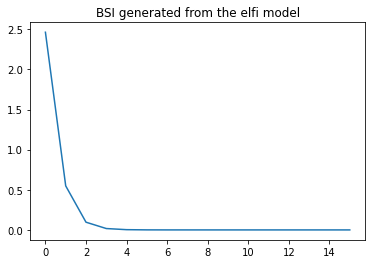

In [44]:
print(SIR.generate(3).shape)

SIR.generate(1)

plt.plot(SIR.generate(1)[0])
plt.title("BSI generated from the elfi model")
plt.show()


In [ ]:
np.warnings.filterwarnings('ignore', category=np.VisibleDeprecationWarning) 
bs = 10
smc = elfi.AdaptiveThresholdSMC(d, batch_size=bs, seed=2, q_threshold=0.995)
smc_samples = smc.sample(1000, max_iter=10)

ABC-SMC Round 1 / 10
Progress [==================================================] 100.0% Complete
ABC-SMC Round 2 / 10
Progress [==================================================] 100.0% Complete
ABC-SMC Round 3 / 10


Method: AdaptiveThresholdSMC
Number of samples: 1000
Number of simulations: 421720
Threshold: 0.000295
Parameter                Mean               2.5%              97.5%
beta:                   0.746              0.729              0.762
gamma:                  0.015              0.010              0.019




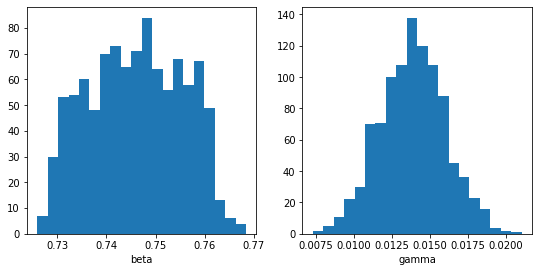

In [35]:
print(smc_samples)


smc_samples.plot_pairs()
#plt.xlim(0.87,0.879)
plt.show()

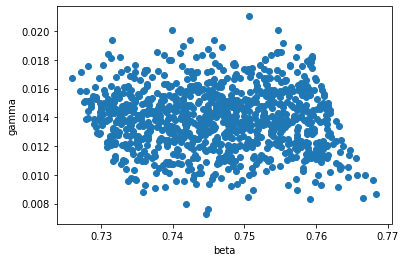

In [39]:
plt.scatter(smc_samples.samples['beta'], smc_samples.samples['gamma'])
plt.xlabel("beta")
plt.ylabel("gamma")
plt.show()

In [108]:
try:
    print("R0:", smc_samples.samples['beta'].mean()/smc_samples.samples['gamma'].mean())
except:
    print("R0:", smc_samples.samples['beta'].mean()/gamma.generate(1))

R0: 39.36542554661984


In [109]:
seed = 7022023
rej = elfi.Rejection(d, batch_size=10, seed=seed)

N = 1000

vis = dict(xlim=[-2,2], ylim=[-1,1])

# You can give the sample method a `vis` keyword to see an animation how the prior transforms towards the
# posterior with a decreasing threshold.
%time result = rej.sample(N, quantile=0.01, vis=vis)

KeyboardInterrupt: 

In [158]:
# current R0
print("R0:", smc_samples.samples['beta'].mean()/smc_samples.samples['gamma'].mean())




plt.hist(smc_samples.samples['beta']/smc_samples.samples['gamma'])
plt.title("RO = beta/gamma")
plt.show()

# seems to be identifiable!!!

KeyError: 'gamma'

In [66]:
# Alternative elfi model with more nodes

elfi.new_model()

bs = 10

# generate data:
OR_hat = get_OR_hat(or_data, clade = "A", dataset = "NORM")
SIR_test = propSIR_simulator(0.72, 0.2, nt = n_weeks, N = pop_size, batch_size = 1)   
bsi_obs = col_to_BSI(SIR_test, OR_hat = OR_hat)#.reshape(-1,1)


#print(BSI_test_obs)
#test_obs = SIR_simulator(beta = 0.7, gamma = 0.2, is_bsi = False, batch_size = bs)
# U(0,1) is a very uninformative prior, since it captures the entirety of possible rate values.
# I know that ecoli transmits quite well. Should I constrain beta more based on this?

beta = elfi.Prior(scipy.stats.uniform, 0, 1)
gamma = elfi.Prior(scipy.stats.uniform, 0, 1)
N = elfi.Constant(pop_size)
nt = elfi.Constant(n_weeks)
SIR = elfi.Simulator(propSIR_simulator, beta, gamma, nt, N, observed = bsi_obs)

theta_c = elfi.Constant(1)
theta_bsi = elfi.Constant(0.5)

#or_mu, or_sd = get_OR_hat_pars(or_data = or_data, clade = "A", dataset = "NORM")
#OR_hat = elfi.RandomVariable(scipy.stats.norm, or_mu, or_sd)

or_data_elfi = elfi.Constant(or_data)
clade = elfi.Constant("A")
dataset = elfi.Constant("NORM")
OR_hat = elfi.Simulator(get_OR_hat, or_data_elfi, clade, dataset)

BSI = elfi.Operation(col_to_BSI, SIR, OR_hat, theta_c, theta_bsi)

S1 = elfi.Summary(I_mean_bsi, BSI)
S2 = elfi.Summary(I_max_bsi, BSI)
#S3 = elfi.Summary(I_var_bsi, BSI)
#S4 = elfi.Summary(S_min_bsi, BSI) we are comparing BSI, can't use S curve to compare.

d = elfi.Distance('euclidean', S1, S2)

elfi.draw(d)

TypeError: __init__() got an unexpected keyword argument 'batch_size'

In [115]:
print(I_mean_bsi(bsi_obs).shape)
print(I_mean(SIR_test).shape)

(1,)
(1,)


In [116]:
print(beta.generate(10).shape)
print(gamma.generate(10).shape)

(10,)
(10,)


In [119]:
SIR.generate(10)[1].shape

(10, 780)

In [120]:
print(bsi_obs.shape)
#print(bsi_obs)
print(BSI.generate(10).shape)
#print(BSI.generate(10))
#print(d.generate(10).shape)
print(S1.generate(10).shape)
print(S2.generate(10).shape)
print(S1.generate(10).ndim)
print(S1.generate(10))

print(type(BSI.generate(10)))
print(type(S1.generate(10)))
print(type(S2.generate(10)))

print(SIR.generate(10)[1].shape)
print(d.generate(10).shape) # this should be (batch_size, 1)
# voiko olla että SIR sekoittaa koko homman? Otetaan S ja R pois ja katsotaan mitä tapahtuu. A: Ei ole siitä kiinni.

(1, 780)
(10, 780)
(10,)
(10,)
1
[8.89353524e-09 1.09796708e-08 1.45552529e-08 5.10861909e-09
 1.40129563e-08 1.95605561e-04 4.38365782e-09 6.82207341e-09
 4.21972857e-09 3.34975113e-08]
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
(10, 780)


ValueError: In executing node 'd': Incompatible data shape for the distance node. Please check summary (XA) and observed (XB) output data dimensions. They have to be at most 2d. Especially ensure that summary nodes outputs 2d data even with batch_size=1. Original error message was: XA and XB must have the same number of columns (i.e. feature dimension.).

(10,)
(10,)
(1, 100)
(10, 100)
(10, 1)
(10,)
2
2
2
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
(10, 1)
[[9.93124567e-01]
 [1.77558617e-01]
 [2.90422880e-03]
 [3.20754251e+01]
 [5.41113174e-01]
 [5.28739072e-02]
 [1.15034854e+00]
 [3.49254612e-03]
 [2.16809157e-01]
 [3.58352174e-02]]
(1, 1)


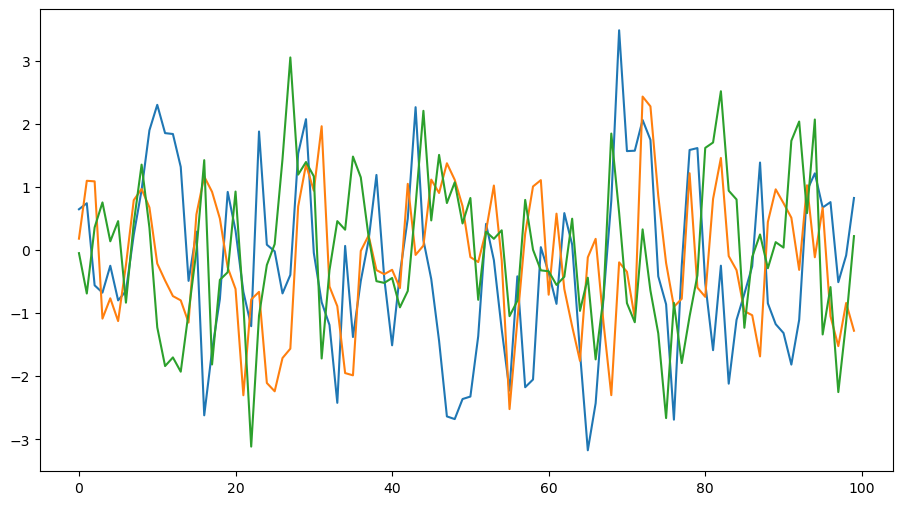

In [476]:
def MA2(t1, t2, n_obs=100, batch_size=1, random_state=None):
    # Make inputs 2d arrays for numpy broadcasting with w
    t1 = np.asanyarray(t1).reshape((-1, 1))
    t2 = np.asanyarray(t2).reshape((-1, 1))
    random_state = random_state or np.random

    w = random_state.randn(batch_size, n_obs+2)  # i.i.d. sequence ~ N(0,1)
    x = w[:, 2:] + t1*w[:, 1:-1] + t2*w[:, :-2]
    return x
# true parameters
t1_true = 0.6
t2_true = 0.2

y_obs = MA2(t1_true, t2_true)


# Plot the observed sequence
plt.figure(figsize=(11, 6));
plt.plot(y_obs.ravel());

# To illustrate the stochasticity, let's plot a couple of more observations with the same true parameters:
plt.plot(MA2(t1_true, t2_true).ravel());
plt.plot(MA2(t1_true, t2_true).ravel());

elfi.new_model()
# a node is defined by giving a distribution from scipy.stats together with any arguments (here 0 and 2)
t1 = elfi.Prior(scipy.stats.uniform, 0, 2)

# ELFI also supports giving the scipy.stats distributions as strings
t2 = elfi.Prior('uniform', 0, 2)

Y = elfi.Simulator(MA2, t1, t2, observed=y_obs)

def autocov(x, lag=1):
    C = np.mean(x[:,lag:] * x[:,:-lag], axis=1)
    return C.reshape(-1,1)

S1 = elfi.Summary(autocov, Y)
S2 = elfi.Summary(autocov, Y, 2)  # the optional keyword lag is given the value 2


# Finish the model with the final node that calculates the squared distance (S1_sim-S1_obs)**2 + (S2_sim-S2_obs)**2
d = elfi.Distance('euclidean', S1, S2)

elfi.draw(d)

print(t1.generate(10).shape)
print(t2.generate(10).shape)
print(y_obs.shape)
#print(y_obs)
print(Y.generate(10).shape)
#print(Y.generate(10))

print(S1.generate(10).shape)
print(d.generate(10).shape)

print(S1.generate(10).ndim)
print(Y.generate(10).ndim)
print(y_obs.ndim)
print(type(y_obs))
print(type(S1.generate(10)))
print(type(S2.generate(10)))

dist_test = (S1.generate(10) - autocov(y_obs))**2
print(dist_test.shape)
print(dist_test)

print(autocov(y_obs).shape)

In [192]:
S2.generate(bs).shape

(10, 1)

In [193]:
BSI_test_obs.shape

(1, 780)

In [194]:
S_obs = I_mean_bsi(BSI_test_obs)
S_obs

array([[0.00111211]])

In [195]:
sim_obs = BSI.generate(bs)
sim_obs.shape

(10, 780)

In [201]:
S_sim = I_mean_bsi(sim_obs)
S_sim

S2_sim = I_max_bsi(sim_obs)

S2_sim

array([[1.10692962e-01],
       [1.91680103e-01],
       [2.11870362e-06],
       [4.32747901e-03],
       [2.89755822e-06],
       [2.75778724e-06],
       [3.16208983e-06],
       [8.18695527e-03],
       [1.18046519e-01],
       [2.26404875e-06]])

In [202]:
(S_sim - S_obs)**2 + (S2_sim - S_obs)**2

array([[1.20079637e-02],
       [3.63276833e-02],
       [2.46882420e-06],
       [1.12295338e-05],
       [2.46711105e-06],
       [2.46741848e-06],
       [2.46653309e-06],
       [5.07564910e-05],
       [1.36737723e-02],
       [2.46851211e-06]])

In [198]:
# summary and observed data must have the same number of columns. So should it actually be (n_obs, batch_size)?

In [204]:
d.generate(bs)

array([[0.00000000e+00, 4.40553754e-02, 1.96518088e-01, 2.79636549e-02,
        4.40555630e-02, 3.53288767e-02, 4.40552100e-02, 4.40550306e-02,
        1.60399540e-01, 4.40553494e-02],
       [4.40553754e-02, 0.00000000e+00, 2.40573424e-01, 1.60981732e-02,
        2.38642179e-07, 7.93839924e-02, 1.68081488e-07, 3.44813886e-07,
        2.04454711e-01, 2.60071912e-08],
       [1.96518088e-01, 2.40573424e-01, 0.00000000e+00, 2.24480122e-01,
        2.40573612e-01, 1.61189502e-01, 2.40573259e-01, 2.40573080e-01,
        3.61202271e-02, 2.40573398e-01],
       [2.79636549e-02, 1.60981732e-02, 2.24480122e-01, 0.00000000e+00,
        1.60983575e-02, 6.32920523e-02, 1.60980072e-02, 1.60978285e-02,
        1.88362110e-01, 1.60981473e-02],
       [4.40555630e-02, 2.38642179e-07, 2.40573612e-01, 1.60983575e-02,
        0.00000000e+00, 7.93841803e-02, 3.72071765e-07, 5.52832271e-07,
        2.04454899e-01, 2.59970860e-07],
       [3.53288767e-02, 7.93839924e-02, 1.61189502e-01, 6.32920523e-02,
   

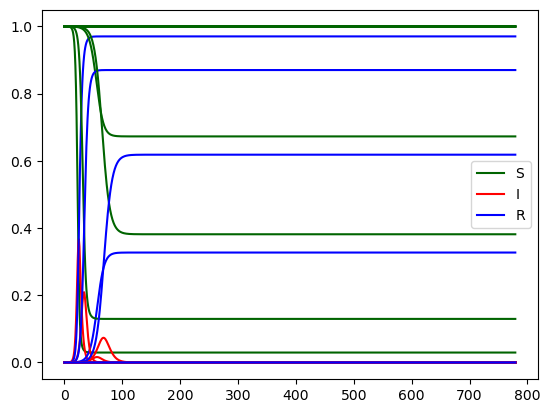

In [104]:

test = SIR.generate(batch_size = bs)

for b in range(0, bs):
    
    if b == 0:
        plt.plot([t for t in range(0, nt.generate())], test[0][b], color = "darkgreen", label = "S")
        plt.plot([t for t in range(0, nt.generate())], test[1][b], color = "red", label = "I")
        plt.plot([t for t in range(0, nt.generate())], test[2][b], color = "blue", label = "R")
    else:
        plt.plot([t for t in range(0, nt.generate())], test[0][b], color = "darkgreen")
        plt.plot([t for t in range(0, nt.generate())], test[1][b], color = "red")
        plt.plot([t for t in range(0, nt.generate())], test[2][b], color = "blue")        

plt.legend()
plt.show()


In [109]:
S1.generate(bs)

array([[5.88827263e-09],
       [3.31515464e-04],
       [8.87425091e-09],
       [9.94770441e-03],
       [5.97900808e-04],
       [5.19238455e-04],
       [2.53812261e-08],
       [1.06350955e-08],
       [2.02353919e-08],
       [7.32039107e-09]])

In [108]:
d.generate(bs) # this does not look good. it is shaped bs*bs

array([[0.00000000e+00, 3.39240333e-01, 7.45524487e-02, 3.39239346e-01,
        1.00204394e-01, 3.39240730e-01, 3.38766490e-01, 3.39239960e-01,
        3.39240068e-01, 3.31650404e-01],
       [3.39240333e-01, 0.00000000e+00, 2.64880890e-01, 9.87652636e-07,
        2.39067531e-01, 3.97057685e-07, 4.81027128e-04, 3.73125827e-07,
        2.64838048e-07, 7.82919375e-03],
       [7.45524487e-02, 2.64880890e-01, 0.00000000e+00, 2.64879903e-01,
        2.66746279e-02, 2.64881287e-01, 2.64405642e-01, 2.64880517e-01,
        2.64880625e-01, 2.57258816e-01],
       [3.39239346e-01, 9.87652636e-07, 2.64879903e-01, 0.00000000e+00,
        2.39066544e-01, 1.38470991e-06, 4.80058487e-04, 6.14526821e-07,
        7.22833585e-07, 7.82824147e-03],
       [1.00204394e-01, 2.39067531e-01, 2.66746279e-02, 2.39066544e-01,
        0.00000000e+00, 2.39067928e-01, 2.38594443e-01, 2.39067158e-01,
        2.39067267e-01, 2.31497589e-01],
       [3.39240730e-01, 3.97057685e-07, 2.64881287e-01, 1.38470991e-06,
   

In [105]:
smc = elfi.AdaptiveThresholdSMC(d, batch_size=bs, seed=2, q_threshold=0.995)
smc_samples = smc.sample(1000, max_iter=10)

In [106]:
#vis = dict(xlim=[-2,2], ylim=[-1,1]) # not implemented for SMC
smc_samples = smc.sample(1000, max_iter=10)

ABC-SMC Round 1 / 10
Progress [==================================================] 100.0% Complete
ABC-SMC Round 2 / 10


TypeError: only size-1 arrays can be converted to Python scalars

In [ ]:
rej = elfi.Rejection(d, batch_size=10, seed=20223)
N = 1000

vis = dict(xlim=[0,1], ylim=[0,1])

# You can give the sample method a `vis` keyword to see an animation how the prior transforms towards the
# posterior with a decreasing threshold.
%time result = rej.sample(N, quantile=0.01, vis=vis)

In [ ]:
# current R0
print("R0:", smc_samples.samples['beta'].mean()/smc_samples.samples['gamma'].mean())


print(smc_samples)


smc_samples.plot_pairs()
plt.show()

plt.hist(smc_samples.samples['beta']/smc_samples.samples['gamma'])
plt.title("RO = beta/gamma")
plt.show()

In [ ]:
#adj = elfi.adjust_posterior(sample=smc_samples, model=elfi.get_model(), summary_names=['S1'])


$$R_0 = \frac{\beta}{\gamma}$$


In [96]:
N = 200
#vis = dict(xlim=[-4,4], ylim=[-4,4])
%time result = rej.sample(N, quantile=0.01)

 /tmp/ipykernel_10957/3318330508.py:19: RuntimeWarning:overflow encountered in multiply
 /tmp/ipykernel_10957/3318330508.py:25: RuntimeWarning:overflow encountered in multiply
 /tmp/ipykernel_10957/3318330508.py:25: RuntimeWarning:invalid value encountered in subtract


Progress [==================================================] 100.0% Complete
CPU times: user 44.2 s, sys: 4.94 s, total: 49.2 s
Wall time: 43.7 s


In [102]:
print(result.samples['beta'].mean())
print(result.samples['gamma'].mean())
print("R0:", result.samples['beta'].mean()/result.samples['gamma'].mean())
result.summary()

1.3316228915740356
0.8962241936479971
R0: 1.4858144881737556
Method: Rejection
Number of samples: 200
Number of simulations: 20000
Threshold: 0.0482
Parameter                Mean               2.5%              97.5%
beta:                   1.332              0.448              2.328
gamma:                  0.896              0.286              1.577



array([[<AxesSubplot: ylabel='beta'>, <AxesSubplot: >],
       [<AxesSubplot: xlabel='beta', ylabel='gamma'>,
        <AxesSubplot: xlabel='gamma'>]], dtype=object)

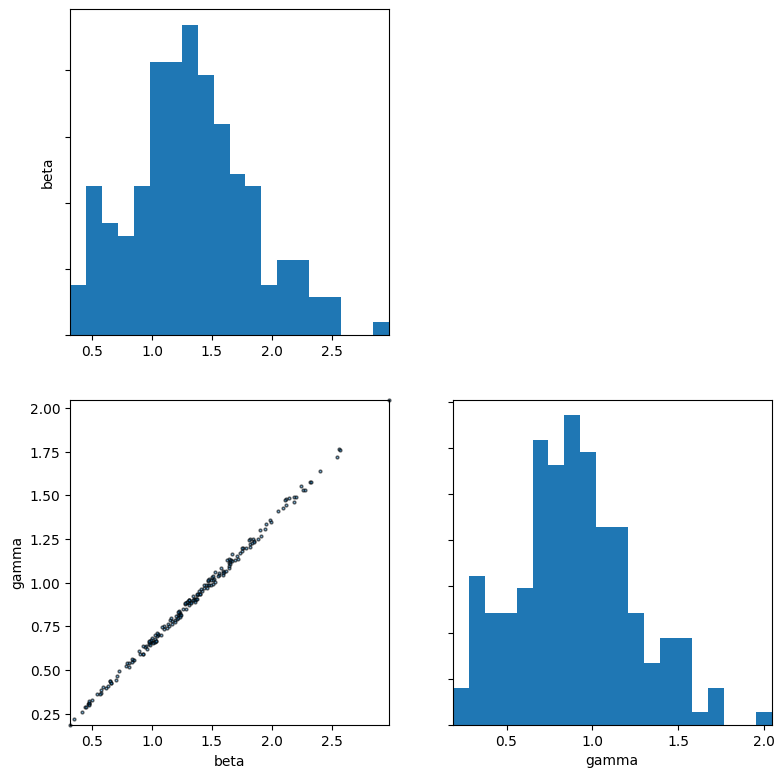

In [103]:
result.plot_pairs()

In [ ]:
#print(np.mean(propSIR_simulator(beta = 1.036, gamma = 0.007)))
print(np.mean(propSIR(beta = result.samples['beta'].mean(), gamma = result.samples['gamma'].mean(), params=params, bsi_params=bsi_pars, is_bsi = True)))

In [ ]:
1.036/0.007

In [ ]:
0.72/0.2

In [ ]:
# let's make a simpler SIR for this
def simpleSIR(beta, alpha, nt = 100, N = 1000, batch_size = 1, random_state = None):
    
    # Use fixed initial values
    S = [N - 1]
    I = [1]
    R = [0]
    
    # Use a fixed length sequence
    T = [i for i in range(0,nt)]
    N = [N]*(len(T) - 1) #*(len(T)-1) # Assume a fixed population size over time.
    
    for t in T[0:(len(T)-1)]: # could this be vectorized for efficiency?
        
        # Update SIR model
        I.append(I[t] + dI(I, S, t, beta, alpha, N))
        R.append(R[t] + dR(I, t, alpha))
        S.append(S[t] + dS(S, I, t, beta, N))
        
    #return S, I, R
    return I
def sse(y1, y2):
    
    (np.array(y1) - np.array(y2))**2
    
def sumstat(y):
    
    #return np.mean(y)
    return np.max(y)

# Define simulator (can ELFI handle multiple y:s?)
SIR_obs = simpleSIR(beta = 0.5, alpha = 0.2, nt=104)

T = [i for i in range(0,104)] # 1 t = 1 week
plt.plot(T, SIR_obs)
plt.title("SIR obs, I")
plt.xlabel("t (weeks)")
plt.show()

# Questions

**Q**: Onko batch-size argumentti tarpeellinen? Jokainen SIR simulaatio tuottaa täsmälleen saman käyrän eli eipä ole kovin stokastistista tämä :( Tai periaatteessa voin vain käyttää jotain `rep` tyyppistä funktiota suoraan.


# SIR model with a carrier compartment
